In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -------------------------------------------------
# Create Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=False)

num_states = env.observation_space.n
num_actions = env.action_space.n

In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100

In [4]:
# -------------------------------------------------
# Initialize Q-table and episode rewards
# -------------------------------------------------

Q = np.zeros((num_states, num_actions))

episode_rewards = []

epsilon = epsilon_start

In [5]:
# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy policy.
    """

    if np.random.random() < epsilon:
        # Exploration
        return env.action_space.sample()
    else:
        # Exploitation
        return np.argmax(Q[state])

In [6]:
# -------------------------------------------------
# Generate One Complete Episode
# -------------------------------------------------

def generate_episode(epsilon):
    """
    Generates one episode using the current epsilon-greedy policy.
    Returns a list of (state, action, reward).
    """

    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):

        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode

In [7]:
# -------------------------------------------------
# Monte Carlo Control
# -------------------------------------------------

for episode_num in range(num_episodes):

    # Generate a complete episode
    episode = generate_episode(epsilon)

    # Calculate total reward
    total_reward = sum(step[2] for step in episode)
    episode_rewards.append(total_reward)

    # Return accumulated from the end of the episode
    G = 0

    # Process episode backwards
    for state, action, reward in reversed(episode):

        G = reward + gamma * G

        # Incremental Monte Carlo update
        Q[state, action] = Q[state, action] + \
            alpha * (G - Q[state, action])

    # Reduce epsilon gradually
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

In [8]:
# -------------------------------------------------
# Extract Greedy Policy
# -------------------------------------------------

optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)

In [15]:
# -------------------------------------------------
# Display Results
# -------------------------------------------------

def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("Name: Harini S      ")
    print("Register Number:  212223240048    ")

    print("\nLearned Policy:")
    print(policy_grid)

In [16]:
def print_value_function(values):

    print("\nEstimated State-Value Function:")

    print(
        np.round(
            values.reshape(4, 4),
            3
        )
    )

In [17]:
print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)

print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])

print(
    "\nAverage reward over last 1000 episodes:",
    success_rate
)


Final Q-table:
[[0.407 0.329 0.948 0.4  ]
 [0.388 0.    0.958 0.183]
 [0.265 0.968 0.431 0.685]
 [0.443 0.    0.    0.   ]
 [0.177 0.565 0.    0.003]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.871]
 [0.    0.    0.    0.   ]
 [0.53  0.    0.807 0.062]
 [0.608 0.772 0.957 0.   ]
 [0.963 0.99  0.    0.915]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.862 0.99  0.501]
 [0.979 0.99  1.    0.979]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.948 0.958 0.968 0.443]
 [0.565 0.    0.98  0.   ]
 [0.807 0.957 0.99  0.   ]
 [0.    0.99  1.    0.   ]]
Name: Harini S      
Register Number:  212223240048    

Learned Policy:
[['R' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.93


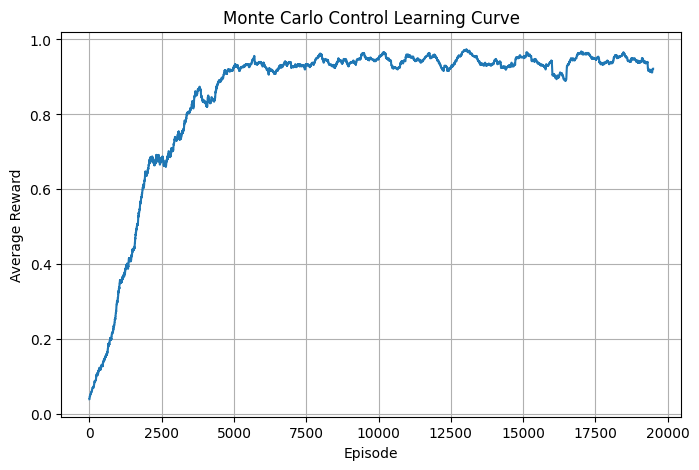

In [12]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "Monte Carlo Control Learning Curve"
)

plt.grid(True)

plt.show()

In [13]:
env.close()